# 06C — ResNet50 @ 320×320 + Focal Loss — FIXED

**Project:** Pedi-CGAM Lite  
**Experiment ID:** `L02_ResNet50_320_FocalLoss`  
**Platform:** Kaggle  
**Target GPU:** Single NVIDIA T4  
**Purpose:** Evaluate Focal Loss on the frozen ResNet50-320 backbone using the exact permanent Stage 02 split.

---

## Scientific question

> Can Focal Loss improve hard and rare pathology ranking while preserving overall Macro-AUPRC on the frozen ResNet50-320 backbone?

This is the second **long-tail loss experiment**. The backbone, resolution, split, optimizer, augmentations, and checkpoint metric stay fixed; only the loss changes.

### Frozen loss-study settings

| Setting | Value |
|---|---|
| Backbone | ResNet50 |
| Pretraining | ImageNet |
| Resolution | **320 × 320** |
| Loss | **Binary Focal Loss** (`gamma = 2.0`, no alpha weighting) |
| Optimizer | AdamW |
| Learning rate | 1e-4 |
| Weight decay | 1e-4 |
| Batch size | **8** |
| Max epochs | **25** |
| Early stopping | 5 epochs |
| Random seed | 42 |
| Mixed precision | Yes |
| Selection metric | Validation 14-pathology Macro-AUPRC |
| Train split | Frozen Stage 02 train |
| Validation split | Frozen Stage 02 validation |
| Calibration split | Not used |
| Official test | Not used |

### Important fairness rules

- The Stage 02 split is verified by SHA-256 before training.
- No horizontal or vertical flips are used.
- Calibration and official test images are not used for training or model selection.
- Threshold-free metrics (`AUPRC`, `AUROC`) drive loss-study model selection.
- Threshold-dependent metrics use a fixed 0.5 threshold only as secondary screening metrics.

### Final Kaggle output

At the end, the notebook creates one file:

`/kaggle/working/L02_ResNet50_320_FocalLoss_All_Outputs.zip`

Download that ZIP and send it back for review before running the next loss experiment.

### Focal Loss definition

We use binary multi-label focal loss directly on logits:

`FL = (1 - p_t)^gamma × BCEWithLogits`

with:

- `gamma = 2.0`
- **no alpha class weighting**

This keeps the experiment focused on hard-example emphasis rather than combining focal loss with an additional class-frequency weighting scheme.

`gamma = 2.0` is fixed before this run and is **not tuned on validation or test data**.

### Recovery/fix note

This fixed version adds an **early focal-loss smoke test** before DICOM caching and uses `torch.nn.functional.binary_cross_entropy_with_logits` directly, preventing the missing-functional-alias runtime failure in the previous version.

The final cell also verifies and packs the **entire experiment output folder into one ZIP**.


In [1]:
# ============================================================
# 1. Install DICOM decoders BEFORE importing pydicom
# ============================================================
%pip install -q -U "pylibjpeg[all]" pyjpegls

print("✅ DICOM decoder packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.3/272.3 kB 19.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
✅ DICOM decoder packages ready.


In [2]:
# ============================================================
# 2. Imports, configuration, reproducibility
# ============================================================
import os
import sys
import gc
import json
import time
import math
import random
import shutil
import hashlib
import zipfile
import platform
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydicom
from pydicom.pixels import apply_modality_lut, apply_voi_lut

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    recall_score,
    confusion_matrix,
)

from tqdm.auto import tqdm

# -------------------------------
# Frozen experiment configuration
# -------------------------------
EXPERIMENT_ID = "L02_ResNet50_320_FocalLoss"
SEED = 42
IMAGE_SIZE = 320
BATCH_SIZE = 8
NUM_WORKERS = 4
MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
FIXED_THRESHOLD = 0.5
USE_AMP = True

EXPECTED_SPLIT_MANIFEST_SHA256 = (
    "3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770"
)

OUTPUT_DIR = Path(f"/kaggle/working/PediCGAM/{EXPERIMENT_ID}")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = Path(
    f"/kaggle/working/PediCGAM_cache/{EXPERIMENT_ID}_{IMAGE_SIZE}"
)

for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Reproducibility is preferred over maximum speed for fair comparison.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("pydicom:", pydicom.__version__)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print(f"GPU memory: {props.total_memory / 1024**3:.2f} GB")
else:
    raise RuntimeError(
        "GPU is not active. In Kaggle Settings, select a GPU accelerator "
        "before running baseline training."
    )


Python: 3.12.13
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
pydicom: 3.0.2
Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB


In [3]:
# ============================================================
# 3. EARLY Focal-Loss smoke test — fail fast before DICOM caching
# ============================================================
# This deliberately runs before expensive preprocessing so any loss-code
# problem is detected within seconds rather than after the cache is built.

_test_logits = torch.tensor(
    [[0.2, -0.8, 1.1], [-0.3, 0.7, -1.2]],
    dtype=torch.float32,
    device=DEVICE,
)
_test_targets = torch.tensor(
    [[1.0, 0.0, 1.0], [0.0, 1.0, 0.0]],
    dtype=torch.float32,
    device=DEVICE,
)

_test_bce = torch.nn.functional.binary_cross_entropy_with_logits(
    _test_logits,
    _test_targets,
    reduction="none",
)
_test_probs = torch.sigmoid(_test_logits)
_test_pt = (
    _test_probs * _test_targets
    + (1.0 - _test_probs) * (1.0 - _test_targets)
)
_test_focal = ((1.0 - _test_pt) ** 2.0) * _test_bce
_test_loss = _test_focal.mean()

if not torch.isfinite(_test_loss):
    raise RuntimeError("Focal-loss preflight produced a non-finite value.")

print("✅ Focal-loss preflight PASS")
print("Synthetic loss:", float(_test_loss.detach().cpu()))

del _test_logits, _test_targets, _test_bce
del _test_probs, _test_pt, _test_focal, _test_loss


✅ Focal-loss preflight PASS
Synthetic loss: 0.05561549589037895


# 3. Required Kaggle inputs

Attach **two inputs** to this notebook:

1. **VinDr-PCXR dataset**
2. **Stage 02 output**, either:
   - the extracted Stage 02 notebook output, or
   - `PediCGAM_Stage02_Fixed_Split_All_Outputs.zip`

The notebook automatically finds both.

It will refuse to train if the split manifest does not match the frozen SHA-256 hash.


In [4]:
# ============================================================
# 4. Locate VinDr-PCXR automatically
# ============================================================
KAGGLE_INPUT = Path("/kaggle/input")

def find_vindr_root(search_root=KAGGLE_INPUT):
    candidates = []

    for f in search_root.rglob("image_labels_train.csv"):
        folder = f.parent
        names = {p.name for p in folder.iterdir() if p.is_file()}
        score = sum(
            x in names
            for x in ["image_labels_train.csv", "annotations_train.csv"]
        )
        candidates.append((score, folder))

    candidates.sort(key=lambda x: (-x[0], len(str(x[1]))))
    return candidates

vindr_candidates = find_vindr_root()

if not vindr_candidates:
    raise FileNotFoundError(
        "VinDr-PCXR was not found under /kaggle/input. "
        "Attach your VinDr-PCXR Kaggle dataset."
    )

DATA_ROOT = vindr_candidates[0][1]
TRAIN_DICOM_DIR = DATA_ROOT / "train"

assert TRAIN_DICOM_DIR.exists()

print("VinDr-PCXR root:")
print(DATA_ROOT)
print("\nTraining DICOM directory:")
print(TRAIN_DICOM_DIR)


VinDr-PCXR root:
/kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0

Training DICOM directory:
/kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0/train


In [5]:
# ============================================================
# 5. Locate and verify the FROZEN Stage 02 split manifest
# ============================================================
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

def find_frozen_manifest(search_root=KAGGLE_INPUT):
    # A. First look for an already-extracted CSV.
    direct_candidates = list(search_root.rglob("fixed_split_manifest.csv"))

    for p in direct_candidates:
        digest = sha256_file(p)
        if digest == EXPECTED_SPLIT_MANIFEST_SHA256:
            return p, "direct_csv", None

    # B. If not found, inspect ZIP files and extract matching manifest.
    for zip_path in search_root.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zip_path, "r") as z:
                possible = [
                    n for n in z.namelist()
                    if n.endswith("fixed_split_manifest.csv")
                ]
                for member in possible:
                    raw = z.read(member)
                    digest = hashlib.sha256(raw).hexdigest()

                    if digest == EXPECTED_SPLIT_MANIFEST_SHA256:
                        extract_dir = Path(
                            "/kaggle/working/stage02_manifest_extracted"
                        )
                        extract_dir.mkdir(parents=True, exist_ok=True)
                        target = extract_dir / "fixed_split_manifest.csv"
                        target.write_bytes(raw)
                        return target, "zip", zip_path
        except zipfile.BadZipFile:
            continue

    return None, None, None

MANIFEST_PATH, MANIFEST_SOURCE, MANIFEST_CONTAINER = find_frozen_manifest()

if MANIFEST_PATH is None:
    raise FileNotFoundError(
        "The frozen Stage 02 fixed_split_manifest.csv was not found. "
        "Attach the saved Stage 02 output/ZIP to this Kaggle notebook."
    )

manifest_hash = sha256_file(MANIFEST_PATH)

print("Manifest:", MANIFEST_PATH)
print("Source type:", MANIFEST_SOURCE)
if MANIFEST_CONTAINER is not None:
    print("Found inside:", MANIFEST_CONTAINER)
print("SHA-256:", manifest_hash)

if manifest_hash != EXPECTED_SPLIT_MANIFEST_SHA256:
    raise RuntimeError(
        "STOP: split manifest hash does not match the frozen Stage 02 split."
    )

print("\n✅ FROZEN STAGE 02 SPLIT VERIFIED.")


Manifest: /kaggle/input/notebooks/kalloldaskushol/02-fixed-train-validation-calibration-split/PediCGAM/stage02_fixed_split/splits/fixed_split_manifest.csv
Source type: direct_csv
SHA-256: 3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770

✅ FROZEN STAGE 02 SPLIT VERIFIED.


In [6]:
# ============================================================
# 6. Load labels and frozen split
# ============================================================
labels = pd.read_csv(DATA_ROOT / "image_labels_train.csv")
manifest = pd.read_csv(MANIFEST_PATH)

NON_LABEL_COLUMNS = ["image_id", "rad_ID"]
LABEL_COLUMNS = [
    c for c in labels.columns
    if c not in NON_LABEL_COLUMNS
]

assert len(LABEL_COLUMNS) == 15
assert "No finding" in LABEL_COLUMNS

PATHOLOGY_COLUMNS = [
    c for c in LABEL_COLUMNS
    if c != "No finding"
]

df = manifest.merge(
    labels,
    on="image_id",
    how="left",
    validate="one_to_one"
)

if df[LABEL_COLUMNS].isna().any().any():
    raise RuntimeError("Some manifest image IDs did not match label rows.")

split_counts = df["split"].value_counts()

print("Split counts:")
display(split_counts.to_frame("images"))

assert int(split_counts["train"]) == 5408
assert int(split_counts["validation"]) == 1159
assert int(split_counts["calibration"]) == 1161

train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df = df[df["split"] == "validation"].copy().reset_index(drop=True)

# IMPORTANT: calibration rows are deliberately not passed into datasets.
print("\nTraining images:", len(train_df))
print("Validation images:", len(val_df))
print("Calibration images present in manifest but NOT used:",
      int(split_counts["calibration"]))

print("\n15 model outputs:")
for i, c in enumerate(LABEL_COLUMNS, 1):
    print(f"{i:02d}. {c}")


Split counts:


,images
split,
train,5408
calibration,1161
validation,1159



Training images: 5408
Validation images: 1159
Calibration images present in manifest but NOT used: 1161

15 model outputs:
01. No finding
02. Bronchitis
03. Brocho-pneumonia
04. Other disease
05. Bronchiolitis
06. Situs inversus
07. Pneumonia
08. Pleuro-pneumonia
09. Diagphramatic hernia
10. Tuberculosis
11. Congenital emphysema
12. CPAM
13. Hyaline membrane disease
14. Mediastinal tumor
15. Lung tumor


In [7]:
# ============================================================
# 7. Load frozen pathology head / middle / tail groups
# ============================================================
def load_stage02_csv(filename):
    # Search extracted files first
    matches = list(KAGGLE_INPUT.rglob(filename))
    if matches:
        return pd.read_csv(matches[0])

    # Search any ZIP
    for zp in KAGGLE_INPUT.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zp, "r") as z:
                members = [n for n in z.namelist() if n.endswith(filename)]
                if members:
                    import io
                    return pd.read_csv(io.BytesIO(z.read(members[0])))
        except zipfile.BadZipFile:
            pass

    return None

rarity_groups = load_stage02_csv(
    "frozen_pathology_head_middle_tail_groups.csv"
)

if rarity_groups is None:
    raise FileNotFoundError(
        "Could not locate frozen_pathology_head_middle_tail_groups.csv "
        "from Stage 02."
    )

rarity_groups = rarity_groups[
    ["label", "positive_images", "frequency_rank", "rarity_group"]
].copy()

print("Frozen pathology rarity groups:")
display(rarity_groups)

if set(rarity_groups["label"]) != set(PATHOLOGY_COLUMNS):
    raise RuntimeError(
        "Frozen pathology groups do not match the 14 pathology labels."
    )

GROUP_TO_LABELS = {
    group: rarity_groups.loc[
        rarity_groups["rarity_group"] == group,
        "label"
    ].tolist()
    for group in ["Head", "Middle", "Tail"]
}

print("\nHead:", GROUP_TO_LABELS["Head"])
print("Middle:", GROUP_TO_LABELS["Middle"])
print("Tail:", GROUP_TO_LABELS["Tail"])


Frozen pathology rarity groups:


,label,positive_images,frequency_rank,rarity_group
0,Bronchitis,842,1,Head
1,Brocho-pneumonia,545,2,Head
2,Bronchiolitis,497,3,Head
3,Other disease,412,4,Head
4,Pneumonia,392,5,Head
5,Hyaline membrane disease,19,6,Middle
6,Tuberculosis,14,7,Middle
7,Situs inversus,11,8,Middle
8,Mediastinal tumor,8,9,Middle
9,Pleuro-pneumonia,6,10,Middle



Head: ['Bronchitis', 'Brocho-pneumonia', 'Bronchiolitis', 'Other disease', 'Pneumonia']
Middle: ['Hyaline membrane disease', 'Tuberculosis', 'Situs inversus', 'Mediastinal tumor', 'Pleuro-pneumonia']
Tail: ['CPAM', 'Lung tumor', 'Diagphramatic hernia', 'Congenital emphysema']


In [8]:
# ============================================================
# 8. Build DICOM path map and verify every train/validation file
# ============================================================
dicom_paths = {
    p.stem: p
    for p in TRAIN_DICOM_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in {".dicom", ".dcm"}
}

required_ids = set(train_df["image_id"]) | set(val_df["image_id"])
missing_files = sorted(required_ids - set(dicom_paths.keys()))

print("DICOM files indexed:", len(dicom_paths))
print("Train+validation IDs required:", len(required_ids))
print("Missing files:", len(missing_files))

if missing_files:
    print("Examples:", missing_files[:20])
    raise FileNotFoundError(
        "One or more frozen split images are missing from the DICOM directory."
    )

print("✅ All training and validation DICOM files are present.")


DICOM files indexed: 7728
Train+validation IDs required: 6567
Missing files: 0
✅ All training and validation DICOM files are present.


# 9. Preprocessing policy

To keep all four Round-2 finalists fair, we will use this exact pipeline later for ResNet50, DenseNet121, EfficientNet-B0, and ConvNeXt-Tiny.

### DICOM → model input

1. Decode DICOM pixels
2. Apply modality LUT when available
3. Apply VOI LUT when available
4. Correct `MONOCHROME1`
5. Robust percentile clipping
6. Normalize to `[0, 1]`
7. Resize to `320 × 320`
8. Cache as uint8 grayscale
9. During training only:
   - small affine transformation
   - mild brightness/contrast variation
10. Repeat grayscale to 3 channels
11. Apply standard ImageNet normalization

### Anatomical safety

**No horizontal flip. No vertical flip.**

This is particularly important because `Situs inversus` is one of the prediction labels.


In [9]:
# ============================================================
# 10. DICOM preprocessing helper
# ============================================================
def dicom_to_uint8_320(path, output_size=IMAGE_SIZE):
    ds = pydicom.dcmread(str(path))

    arr = ds.pixel_array

    # Apply modality transformation if DICOM metadata supports it.
    try:
        arr = apply_modality_lut(arr, ds)
    except Exception:
        arr = np.asarray(arr)

    # Apply VOI transformation if present.
    try:
        arr = apply_voi_lut(arr, ds)
    except Exception:
        arr = np.asarray(arr)

    arr = np.asarray(arr, dtype=np.float32)

    if not np.isfinite(arr).all():
        finite = arr[np.isfinite(arr)]
        fill = float(np.median(finite)) if finite.size else 0.0
        arr = np.nan_to_num(arr, nan=fill, posinf=fill, neginf=fill)

    # MONOCHROME1: low pixel value should display as white.
    # Invert so the stored model image has conventional chest-X-ray polarity.
    if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
        arr = arr.max() + arr.min() - arr

    lo, hi = np.percentile(arr, [0.5, 99.5])

    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(arr.min())
        hi = float(arr.max())

    if hi > lo:
        arr = np.clip(arr, lo, hi)
        arr = (arr - lo) / (hi - lo)
    else:
        arr = np.zeros_like(arr, dtype=np.float32)

    arr = (arr * 255.0).round().astype(np.uint8)

    img = Image.fromarray(arr)
    img = img.resize(
        (output_size, output_size),
        resample=Image.Resampling.BILINEAR
    )

    return np.asarray(img, dtype=np.uint8)


In [10]:
# ============================================================
# 11. Cache preprocessed 320×320 train/validation images
# ============================================================
# Cache is deliberately outside the experiment output ZIP.
# It speeds training but is not a scientific output.

def cache_images(dataframe, split_name):
    split_cache = CACHE_DIR / split_name
    split_cache.mkdir(parents=True, exist_ok=True)

    failures = []

    for image_id in tqdm(
        dataframe["image_id"].tolist(),
        desc=f"Caching {split_name}"
    ):
        target = split_cache / f"{image_id}.npy"

        if target.exists():
            continue

        try:
            arr = dicom_to_uint8_320(
                dicom_paths[str(image_id)],
                IMAGE_SIZE
            )
            np.save(target, arr, allow_pickle=False)
        except Exception as e:
            failures.append({
                "split": split_name,
                "image_id": image_id,
                "error": f"{type(e).__name__}: {e}",
            })

    return pd.DataFrame(failures)

train_cache_fail = cache_images(train_df, "train")
val_cache_fail = cache_images(val_df, "validation")

cache_failures = pd.concat(
    [train_cache_fail, val_cache_fail],
    ignore_index=True
)

cache_failures.to_csv(
    TABLE_DIR / "preprocessing_cache_failures.csv",
    index=False
)

print("Preprocessing failures:", len(cache_failures))

if len(cache_failures):
    display(cache_failures.head(30))
    raise RuntimeError(
        "Preprocessing failed for one or more images. "
        "Do not train until this is resolved."
    )

print("✅ Train and validation caches are complete.")


Caching train:   0%|          | 0/5408 [00:00<?, ?it/s]

Caching validation:   0%|          | 0/1159 [00:00<?, ?it/s]

Preprocessing failures: 0
✅ Train and validation caches are complete.


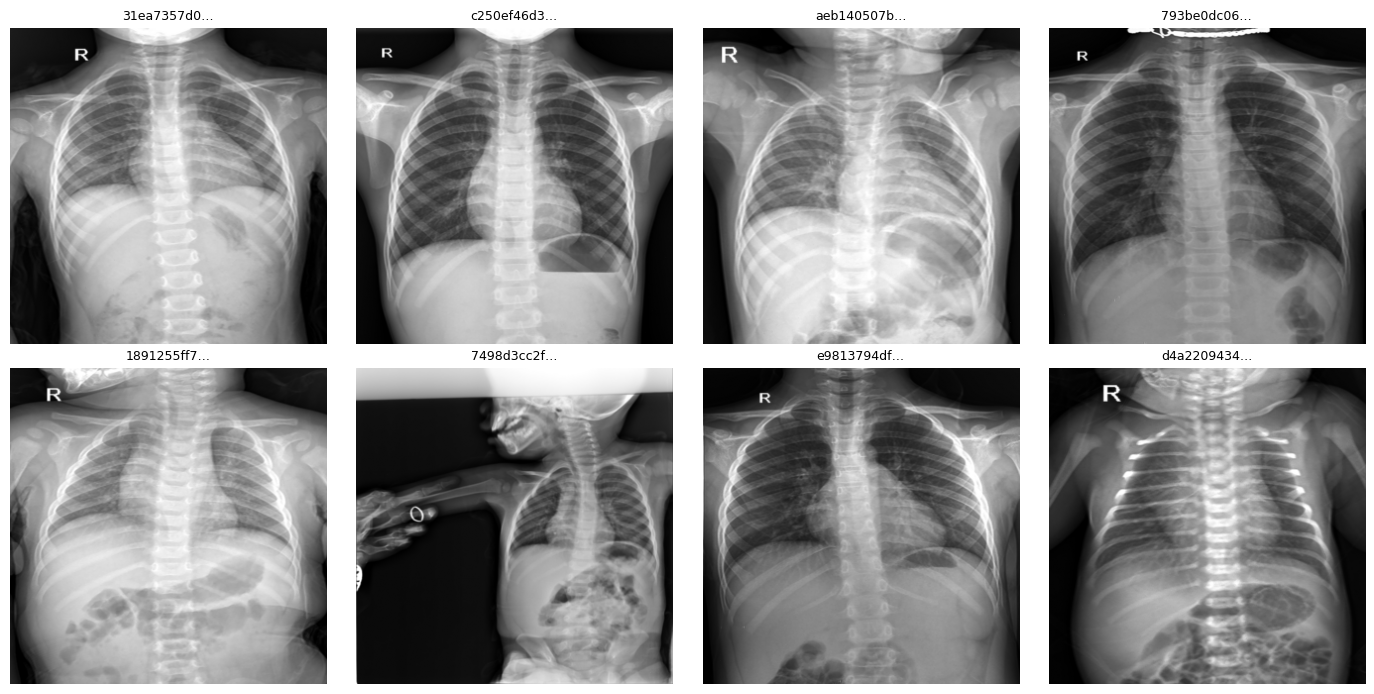

Saved: /kaggle/working/PediCGAM/L02_ResNet50_320_FocalLoss/figures/preprocessing_sanity_check.png


In [11]:
# ============================================================
# 12. Visual preprocessing sanity check
# ============================================================
sample_ids = (
    train_df["image_id"]
    .sample(n=min(8, len(train_df)), random_state=SEED)
    .tolist()
)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for ax, image_id in zip(axes, sample_ids):
    arr = np.load(
        CACHE_DIR / "train" / f"{image_id}.npy",
        allow_pickle=False
    )
    ax.imshow(arr, cmap="gray")
    ax.set_title(str(image_id)[:10] + "…", fontsize=9)
    ax.axis("off")

plt.tight_layout()
preproc_fig = FIG_DIR / "preprocessing_sanity_check.png"
plt.savefig(preproc_fig, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", preproc_fig)


In [12]:
# ============================================================
# 13. Dataset and augmentation definitions
# ============================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.320, 0.225]

train_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=5,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
        fill=0,
    ),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
    ),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])

val_transform = transforms.Compose([
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])

class CachedCXRDataset(Dataset):
    def __init__(
        self,
        dataframe,
        split_name,
        cache_root,
        label_columns,
        transform=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.split_name = split_name
        self.cache_dir = Path(cache_root) / split_name
        self.label_columns = label_columns
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["image_id"])

        arr = np.load(
            self.cache_dir / f"{image_id}.npy",
            allow_pickle=False
        )

        # [H,W] uint8 -> [1,H,W] float -> [3,H,W]
        x = torch.from_numpy(arr).float().unsqueeze(0) / 255.0
        x = x.repeat(3, 1, 1)

        if self.transform is not None:
            x = self.transform(x)

        y = torch.tensor(
            row[self.label_columns].to_numpy(dtype=np.float32),
            dtype=torch.float32
        )

        return x, y, image_id


In [13]:
# ============================================================
# 14. DataLoaders
# ============================================================
train_dataset = CachedCXRDataset(
    train_df,
    "train",
    CACHE_DIR,
    LABEL_COLUMNS,
    transform=train_transform
)

val_dataset = CachedCXRDataset(
    val_df,
    "validation",
    CACHE_DIR,
    LABEL_COLUMNS,
    transform=val_transform
)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    generator=generator,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

x, y, ids = next(iter(train_loader))
print("Batch image tensor:", x.shape, x.dtype)
print("Batch target tensor:", y.shape, y.dtype)
print("Example ID:", ids[0])

assert x.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)
assert y.shape[1] == len(LABEL_COLUMNS)


Train batches: 676
Validation batches: 145
Batch image tensor: torch.Size([8, 3, 320, 320]) torch.float32
Batch target tensor: torch.Size([8, 15]) torch.float32
Example ID: 381333b8dec089970ffbab32e8da3c67


In [14]:
# ============================================================
# 15. Build ImageNet-pretrained ResNet50
# ============================================================
weights = ResNet50_Weights.DEFAULT

try:
    model = resnet50(weights=weights)
except Exception as e:
    raise RuntimeError(
        "Could not load ImageNet-pretrained ResNet50 weights. "
        "Keep Kaggle Internet ON for this baseline notebook."
    ) from e

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, len(LABEL_COLUMNS))
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(model.fc)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

with open(OUTPUT_DIR / "model_summary.txt", "w") as f:
    f.write(str(model))
    f.write(f"\n\nTotal parameters: {total_params:,}\n")
    f.write(f"Trainable parameters: {trainable_params:,}\n")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 109MB/s]


Linear(in_features=2048, out_features=15, bias=True)
Total parameters: 23,538,767
Trainable parameters: 23,538,767


In [15]:
# ============================================================
# 16. Focal Loss, optimizer, scheduler, AMP
# ============================================================
FOCAL_GAMMA = 2.0

class BinaryFocalLoss(nn.Module):
    """
    Multi-label binary focal loss computed from logits.

    FL = (1 - p_t)^gamma * BCEWithLogits

    No alpha weighting is used in this controlled experiment.
    """
    def __init__(self, gamma=2.0, reduction="mean"):
        super().__init__()
        self.gamma = float(gamma)
        self.reduction = reduction

    def forward(self, logits, targets):
        bce = torch.nn.functional.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
        )

        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1.0 - probs) * (1.0 - targets)

        focal_factor = (1.0 - p_t).pow(self.gamma)
        loss = focal_factor * bce

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

criterion = BinaryFocalLoss(
    gamma=FOCAL_GAMMA,
    reduction="mean",
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(USE_AMP and DEVICE.type == "cuda")
)

print("Criterion:", criterion.__class__.__name__)
print("FOCAL_GAMMA:", FOCAL_GAMMA)
print("Alpha weighting: NONE")
print("Optimizer:", optimizer.__class__.__name__)
print("Initial LR:", optimizer.param_groups[0]["lr"])
print("AMP enabled:", scaler.is_enabled())


Criterion: BinaryFocalLoss
FOCAL_GAMMA: 2.0
Alpha weighting: NONE
Optimizer: AdamW
Initial LR: 0.0001
AMP enabled: True


In [16]:
# ============================================================
# 17. Metric helpers
# ============================================================
label_to_index = {
    label: i
    for i, label in enumerate(LABEL_COLUMNS)
}

pathology_indices = [
    label_to_index[c]
    for c in PATHOLOGY_COLUMNS
]

def safe_average_precision(y_true, y_prob):
    if np.unique(y_true).size < 2 and y_true.sum() == 0:
        return np.nan
    try:
        return average_precision_score(y_true, y_prob)
    except Exception:
        return np.nan

def safe_auroc(y_true, y_prob):
    if np.unique(y_true).size < 2:
        return np.nan
    try:
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan

def binary_specificity(y_true, y_pred):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan

def binary_balanced_accuracy(y_true, y_pred):
    sensitivity = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )
    specificity = binary_specificity(y_true, y_pred)
    if np.isnan(specificity):
        return np.nan
    return (sensitivity + specificity) / 2.0

def compute_metrics(y_true, y_prob, threshold=0.5):
    rows = []

    y_pred = (y_prob >= threshold).astype(int)

    for i, label in enumerate(LABEL_COLUMNS):
        yt = y_true[:, i].astype(int)
        yp = y_prob[:, i]
        yh = y_pred[:, i]

        rows.append({
            "label": label,
            "positive_validation_images": int(yt.sum()),
            "AUPRC": safe_average_precision(yt, yp),
            "AUROC": safe_auroc(yt, yp),
            "F1_at_0.5": f1_score(
                yt, yh, zero_division=0
            ),
            "Sensitivity_at_0.5": recall_score(
                yt, yh, zero_division=0
            ),
            "Specificity_at_0.5": binary_specificity(yt, yh),
            "BalancedAccuracy_at_0.5": binary_balanced_accuracy(yt, yh),
        })

    per_class = pd.DataFrame(rows)

    pathology_table = per_class[
        per_class["label"].isin(PATHOLOGY_COLUMNS)
    ].copy()

    summary = {
        "all15_macro_AUPRC": float(
            per_class["AUPRC"].mean(skipna=True)
        ),
        "pathology14_macro_AUPRC": float(
            pathology_table["AUPRC"].mean(skipna=True)
        ),
        "pathology14_macro_AUROC": float(
            pathology_table["AUROC"].mean(skipna=True)
        ),
        "pathology14_macro_F1_at_0.5": float(
            pathology_table["F1_at_0.5"].mean(skipna=True)
        ),
        "pathology14_macro_sensitivity_at_0.5": float(
            pathology_table["Sensitivity_at_0.5"].mean(skipna=True)
        ),
        "pathology14_macro_specificity_at_0.5": float(
            pathology_table["Specificity_at_0.5"].mean(skipna=True)
        ),
        "pathology14_macro_balanced_accuracy_at_0.5": float(
            pathology_table["BalancedAccuracy_at_0.5"].mean(skipna=True)
        ),
    }

    group_rows = []

    for group in ["Head", "Middle", "Tail"]:
        group_labels = GROUP_TO_LABELS[group]
        group_table = per_class[
            per_class["label"].isin(group_labels)
        ]

        group_rows.append({
            "group": group,
            "n_classes": len(group_labels),
            "macro_AUPRC": float(
                group_table["AUPRC"].mean(skipna=True)
            ),
            "macro_AUROC": float(
                group_table["AUROC"].mean(skipna=True)
            ),
            "macro_F1_at_0.5": float(
                group_table["F1_at_0.5"].mean(skipna=True)
            ),
            "macro_sensitivity_at_0.5": float(
                group_table["Sensitivity_at_0.5"].mean(skipna=True)
            ),
            "macro_specificity_at_0.5": float(
                group_table["Specificity_at_0.5"].mean(skipna=True)
            ),
        })

    groups = pd.DataFrame(group_rows)

    return per_class, summary, groups


In [17]:
# ============================================================
# 18. One training epoch and one validation pass
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()

    total_loss = 0.0
    n_samples = 0

    progress = tqdm(loader, leave=False, desc="Train")

    for images, targets, _ in progress:
        images = images.to(
            DEVICE,
            non_blocking=True
        )
        targets = targets.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(USE_AMP and DEVICE.type == "cuda")
        ):
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = images.size(0)
        total_loss += loss.item() * bs
        n_samples += bs

        progress.set_postfix(
            loss=f"{total_loss / max(n_samples, 1):.4f}"
        )

    return total_loss / n_samples

@torch.no_grad()
def validate_model(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    n_samples = 0

    all_true = []
    all_prob = []
    all_ids = []

    progress = tqdm(loader, leave=False, desc="Validation")

    for images, targets, image_ids in progress:
        images = images.to(
            DEVICE,
            non_blocking=True
        )
        targets_gpu = targets.to(
            DEVICE,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(USE_AMP and DEVICE.type == "cuda")
        ):
            logits = model(images)
            loss = criterion(logits, targets_gpu)

        probs = torch.sigmoid(logits)

        bs = images.size(0)
        total_loss += loss.item() * bs
        n_samples += bs

        all_true.append(targets.numpy())
        all_prob.append(probs.float().cpu().numpy())
        all_ids.extend(list(image_ids))

    y_true = np.concatenate(all_true, axis=0)
    y_prob = np.concatenate(all_prob, axis=0)

    per_class, summary, groups = compute_metrics(
        y_true,
        y_prob,
        FIXED_THRESHOLD
    )

    return (
        total_loss / n_samples,
        y_true,
        y_prob,
        all_ids,
        per_class,
        summary,
        groups,
    )


# 19. Train ResNet50

The model checkpoint is selected using:

> **Validation 14-pathology Macro-AUPRC**

This is the primary metric because the task is severely imbalanced.

Training stops after 5 epochs without an improvement in that metric.


In [18]:
# ============================================================
# 20. Training loop with early stopping
# ============================================================
BEST_MODEL_PATH = OUTPUT_DIR / "best_model.pth"

history = []
best_metric = -np.inf
best_epoch = None
epochs_without_improvement = 0

training_start = time.time()

if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.time()

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler
    )

    (
        val_loss,
        y_true,
        y_prob,
        val_ids_epoch,
        per_class_epoch,
        summary_epoch,
        groups_epoch,
    ) = validate_model(
        model,
        val_loader,
        criterion
    )

    selection_metric = summary_epoch[
        "pathology14_macro_AUPRC"
    ]

    scheduler.step(selection_metric)

    current_lr = optimizer.param_groups[0]["lr"]
    elapsed = time.time() - epoch_start

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": val_loss,
        "pathology14_macro_AUPRC": selection_metric,
        "all15_macro_AUPRC": summary_epoch[
            "all15_macro_AUPRC"
        ],
        "pathology14_macro_AUROC": summary_epoch[
            "pathology14_macro_AUROC"
        ],
        "head_macro_AUPRC": float(
            groups_epoch.loc[
                groups_epoch["group"] == "Head",
                "macro_AUPRC"
            ].iloc[0]
        ),
        "middle_macro_AUPRC": float(
            groups_epoch.loc[
                groups_epoch["group"] == "Middle",
                "macro_AUPRC"
            ].iloc[0]
        ),
        "tail_macro_AUPRC": float(
            groups_epoch.loc[
                groups_epoch["group"] == "Tail",
                "macro_AUPRC"
            ].iloc[0]
        ),
        "learning_rate": current_lr,
        "epoch_seconds": elapsed,
    }
    history.append(row)

    improved = selection_metric > best_metric + 1e-8

    if improved:
        best_metric = selection_metric
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "experiment_id": EXPERIMENT_ID,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "selection_metric_name": (
                    "validation_pathology14_macro_AUPRC"
                ),
                "selection_metric_value": best_metric,
                "label_columns": LABEL_COLUMNS,
                "pathology_columns": PATHOLOGY_COLUMNS,
                "image_size": IMAGE_SIZE,
                "split_manifest_sha256": manifest_hash,
                "random_seed": SEED,
            },
            BEST_MODEL_PATH
        )
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"macro_AUPRC14={selection_metric:.4f} | "
        f"head={row['head_macro_AUPRC']:.4f} | "
        f"middle={row['middle_macro_AUPRC']:.4f} | "
        f"tail={row['tail_macro_AUPRC']:.4f} | "
        f"lr={current_lr:.2e} | "
        f"{'BEST' if improved else ''}"
    )

    # Save history continuously in case Kaggle is interrupted.
    pd.DataFrame(history).to_csv(
        OUTPUT_DIR / "training_history.csv",
        index=False
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(
            f"\nEarly stopping: no improvement for "
            f"{EARLY_STOPPING_PATIENCE} epochs."
        )
        break

training_seconds = time.time() - training_start

print("\nTraining finished.")
print("Best epoch:", best_epoch)
print(f"Best validation pathology14 Macro-AUPRC: {best_metric:.6f}")
print(f"Total training time: {training_seconds / 60:.2f} minutes")


Train:   0%|          | 0/676 [00:00<?, ?it/s]

Validation:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 01/25 | train_loss=0.0363 | val_loss=0.0323 | macro_AUPRC14=0.1084 | head=0.1943 | middle=0.1047 | tail=0.0055 | lr=1.00e-04 | BEST


Train:   0%|          | 0/676 [00:00<?, ?it/s]

Validation:   0%|          | 0/145 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 09/25 | train_loss=0.0136 | val_loss=0.0533 | macro_AUPRC14=0.1861 | head=0.1774 | middle=0.3069 | tail=0.0459 | lr=5.00e-05 | 


Train:   0%|          | 0/676 [00:00<?, ?it/s]

Validation:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 10/25 | train_loss=0.0095 | val_loss=0.0567 | macro_AUPRC14=0.1599 | head=0.1836 | middle=0.2276 | tail=0.0456 | lr=5.00e-05 | 

Early stopping: no improvement for 5 epochs.

Training finished.
Best epoch: 5
Best validation pathology14 Macro-AUPRC: 0.216165
Total training time: 9.50 minutes


In [19]:
# ============================================================
# 21. Restore BEST checkpoint and run final validation
# ============================================================
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])

(
    final_val_loss,
    final_y_true,
    final_y_prob,
    final_val_ids,
    final_per_class,
    final_summary,
    final_groups,
) = validate_model(
    model,
    val_loader,
    criterion
)

print("BEST CHECKPOINT FINAL VALIDATION")
print("=" * 60)
print("Best epoch:", checkpoint["epoch"])
print("Validation loss:", final_val_loss)
print(
    "14-pathology Macro-AUPRC:",
    final_summary["pathology14_macro_AUPRC"]
)
print(
    "14-pathology Macro-AUROC:",
    final_summary["pathology14_macro_AUROC"]
)

display(final_groups)
display(final_per_class)


Validation:   0%|          | 0/145 [00:00<?, ?it/s]

BEST CHECKPOINT FINAL VALIDATION
Best epoch: 5
Validation loss: 0.033806673882688244
14-pathology Macro-AUPRC: 0.21616537502871222
14-pathology Macro-AUROC: 0.8495176213321699


,group,n_classes,macro_AUPRC,macro_AUROC,macro_F1_at_0.5,macro_sensitivity_at_0.5,macro_specificity_at_0.5
0,Head,5,0.212691,0.749812,0.024505,0.013319,0.997327
1,Middle,5,0.347567,0.911998,0.000000,0.000000,0.999135
2,Tail,4,0.056256,0.896049,0.000000,0.000000,1.000000


,label,positive_validation_images,AUPRC,AUROC,F1_at_0.5,Sensitivity_at_0.5,Specificity_at_0.5,BalancedAccuracy_at_0.5
0,No finding,772,0.855310,0.761772,0.820625,0.968912,0.217054,0.592983
1,Bronchitis,127,0.230006,0.719977,0.028777,0.015748,0.990310,0.503029
2,Brocho-pneumonia,82,0.200850,0.776995,0.000000,0.000000,0.998143,0.499071
3,Other disease,62,0.191282,0.708332,0.000000,0.000000,1.000000,0.500000
4,Bronchiolitis,75,0.114492,0.693524,0.000000,0.000000,1.000000,0.500000
5,Situs inversus,1,0.043478,0.981002,0.000000,0.000000,1.000000,0.500000
6,Pneumonia,59,0.326826,0.850231,0.093750,0.050847,0.998182,0.524515
7,Pleuro-pneumonia,1,1.000000,1.000000,0.000000,0.000000,1.000000,0.500000
8,Diagphramatic hernia,1,0.200000,0.996546,0.000000,0.000000,1.000000,0.500000
9,Tuberculosis,2,0.590909,0.996111,0.000000,0.000000,1.000000,0.500000


In [20]:
# ============================================================
# 22. Save final validation predictions
# ============================================================
prediction_data = {
    "image_id": final_val_ids
}

for i, label in enumerate(LABEL_COLUMNS):
    safe = (
        label.lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

    prediction_data[f"true__{safe}"] = final_y_true[:, i].astype(int)
    prediction_data[f"prob__{safe}"] = final_y_prob[:, i]

predictions_df = pd.DataFrame(prediction_data)

predictions_df.to_csv(
    TABLE_DIR / "validation_predictions.csv",
    index=False
)

final_per_class.to_csv(
    TABLE_DIR / "per_class_metrics.csv",
    index=False
)

final_groups.to_csv(
    TABLE_DIR / "head_middle_tail_metrics.csv",
    index=False
)

summary_df = pd.DataFrame(
    [{"metric": k, "value": v}
     for k, v in final_summary.items()]
)

summary_df.to_csv(
    TABLE_DIR / "summary_metrics.csv",
    index=False
)

display(summary_df)


,metric,value
0,all15_macro_AUPRC,0.258775
1,pathology14_macro_AUPRC,0.216165
2,pathology14_macro_AUROC,0.849518
3,pathology14_macro_F1_at_0.5,0.008752
4,pathology14_macro_sensitivity_at_0.5,0.004757
5,pathology14_macro_specificity_at_0.5,0.998736
6,pathology14_macro_balanced_accuracy_at_0.5,0.501747


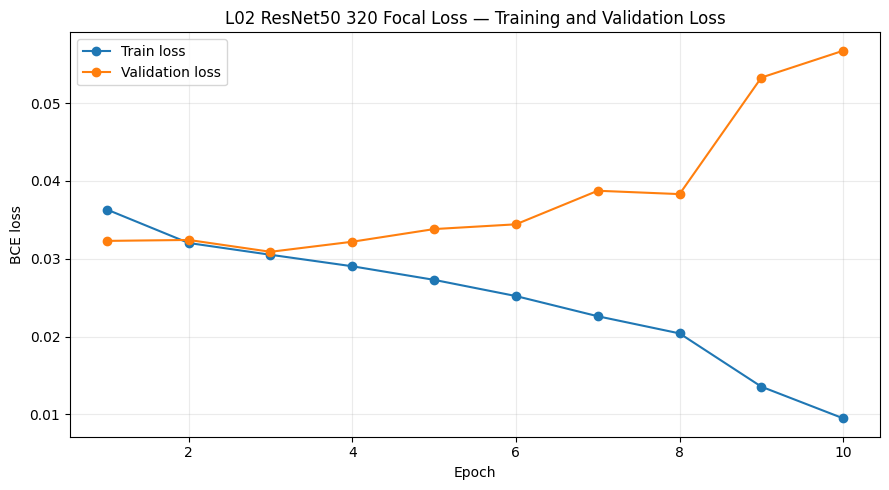

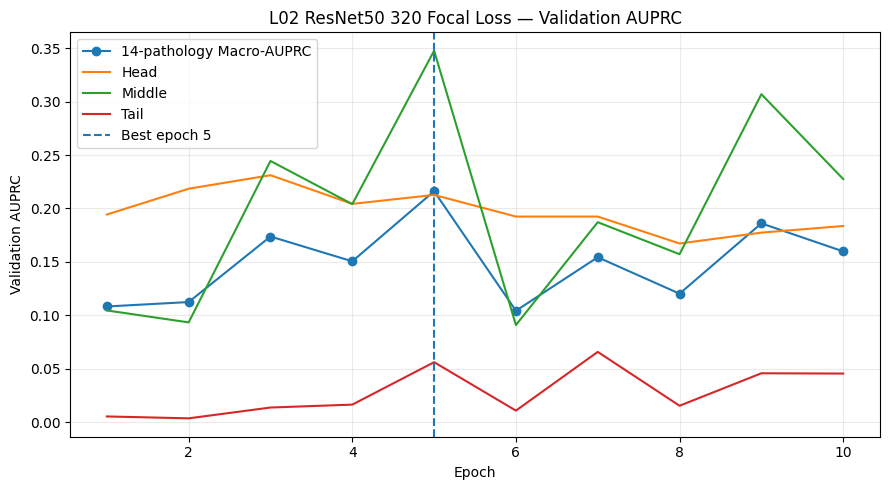

In [21]:
# ============================================================
# 23. Save plots — learning curves
# ============================================================
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train loss"
)
ax.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation loss"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE loss")
ax.set_title("L02 ResNet50 320 Focal Loss — Training and Validation Loss")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
path = FIG_DIR / "training_validation_loss.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    history_df["epoch"],
    history_df["pathology14_macro_AUPRC"],
    marker="o",
    label="14-pathology Macro-AUPRC"
)
ax.plot(
    history_df["epoch"],
    history_df["head_macro_AUPRC"],
    label="Head"
)
ax.plot(
    history_df["epoch"],
    history_df["middle_macro_AUPRC"],
    label="Middle"
)
ax.plot(
    history_df["epoch"],
    history_df["tail_macro_AUPRC"],
    label="Tail"
)
ax.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch {best_epoch}"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation AUPRC")
ax.set_title("L02 ResNet50 320 Focal Loss — Validation AUPRC")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
path = FIG_DIR / "validation_auprc_by_epoch.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()


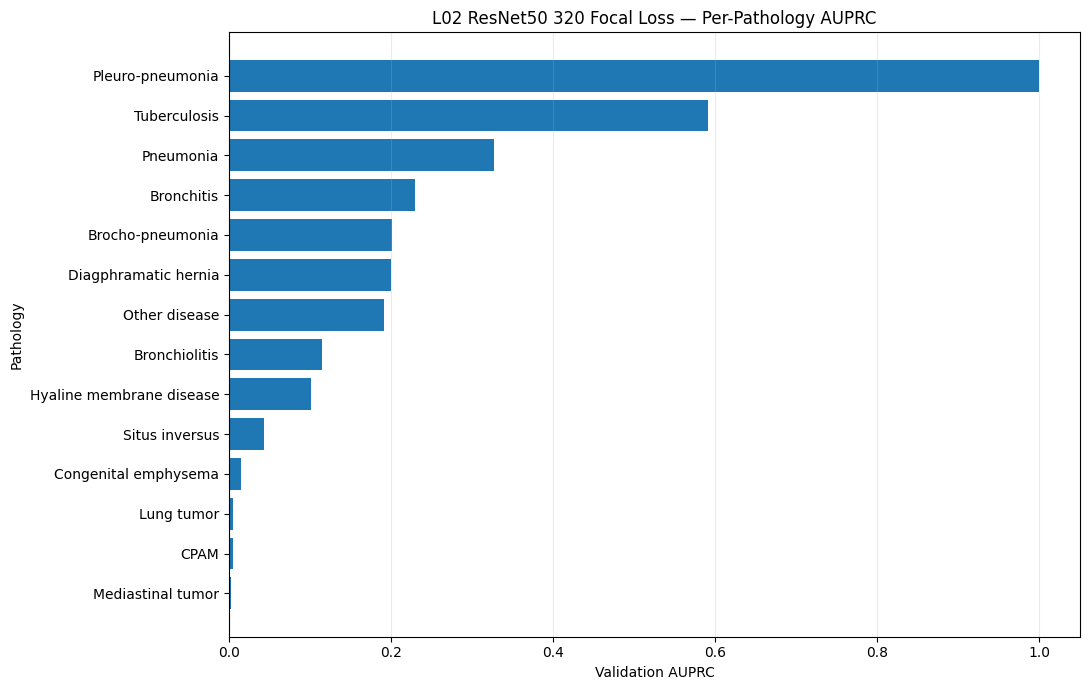

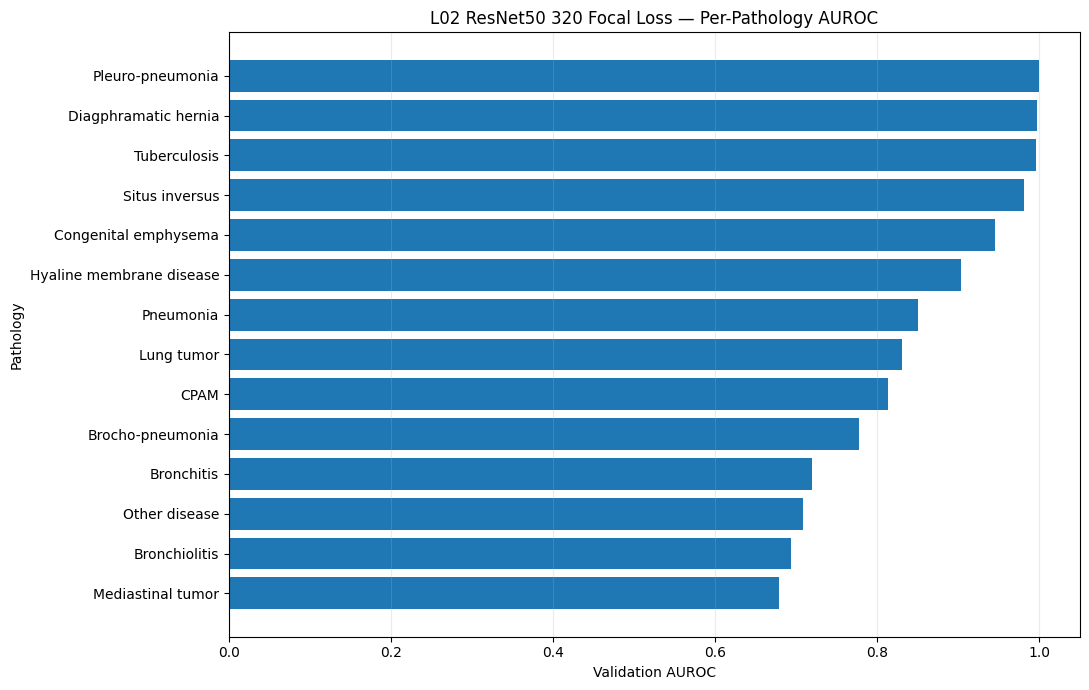

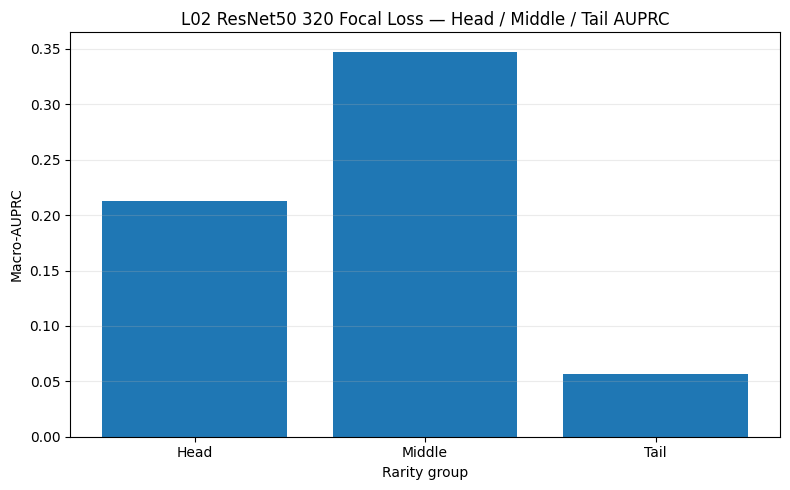

In [22]:
# ============================================================
# 24. Save plots — per-class and rarity-group results
# ============================================================
pathology_metrics = final_per_class[
    final_per_class["label"].isin(PATHOLOGY_COLUMNS)
].copy()

plot_df = pathology_metrics.sort_values("AUPRC")

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_df["label"], plot_df["AUPRC"])
ax.set_xlabel("Validation AUPRC")
ax.set_ylabel("Pathology")
ax.set_title("L02 ResNet50 320 Focal Loss — Per-Pathology AUPRC")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
path = FIG_DIR / "per_pathology_auprc.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

plot_df = pathology_metrics.sort_values("AUROC")

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_df["label"], plot_df["AUROC"])
ax.set_xlabel("Validation AUROC")
ax.set_ylabel("Pathology")
ax.set_title("L02 ResNet50 320 Focal Loss — Per-Pathology AUROC")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
path = FIG_DIR / "per_pathology_auroc.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    final_groups["group"],
    final_groups["macro_AUPRC"]
)
ax.set_ylabel("Macro-AUPRC")
ax.set_xlabel("Rarity group")
ax.set_title("L02 ResNet50 320 Focal Loss — Head / Middle / Tail AUPRC")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
path = FIG_DIR / "head_middle_tail_auprc.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()


In [23]:
# ============================================================
# 25. Save experiment configuration and environment
# ============================================================
peak_gpu_memory_gb = (
    torch.cuda.max_memory_allocated() / 1024**3
    if DEVICE.type == "cuda"
    else None
)

config = {
    "experiment_id": EXPERIMENT_ID,
    "stage": "LongTail_Loss_Study",
    "backbone": "ResNet50",
    "pretraining": "ImageNet / torchvision ResNet50_Weights.DEFAULT",
    "image_size": IMAGE_SIZE,
    "model_outputs": LABEL_COLUMNS,
    "pathology_metrics_exclude": ["No finding"],
    "loss": "BinaryFocalLoss",
    "focal_loss": {
        "gamma": FOCAL_GAMMA,
        "alpha_weighting": None,
        "formulation": "(1-p_t)^gamma * BCEWithLogits",
        "validation_used_for_hyperparameter_selection": False,
        "calibration_used_for_hyperparameter_selection": False,
        "official_test_used_for_hyperparameter_selection": False,
    },
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "seed": SEED,
    "mixed_precision": USE_AMP,
    "fixed_threshold_for_secondary_metrics": FIXED_THRESHOLD,
    "selection_metric": "validation_pathology14_macro_AUPRC",
    "train_images": len(train_df),
    "validation_images": len(val_df),
    "calibration_used": False,
    "official_test_used": False,
    "split_manifest_sha256": manifest_hash,
    "augmentation": {
        "horizontal_flip": False,
        "vertical_flip": False,
        "random_affine_degrees": 5,
        "translation_fraction": 0.03,
        "scale_range": [0.95, 1.05],
        "brightness_jitter": 0.10,
        "contrast_jitter": 0.10,
    },
    "preprocessing": {
        "modality_lut": True,
        "voi_lut_when_available": True,
        "monochrome1_correction": True,
        "percentile_clip": [0.5, 99.5],
        "cached_grayscale_uint8": True,
        "imagenet_normalization": True,
    },
}

with open(OUTPUT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

environment_info = {
    "python": sys.version,
    "platform": platform.platform(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "pydicom": pydicom.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "peak_gpu_memory_gb": peak_gpu_memory_gb,
    "training_seconds": training_seconds,
    "training_minutes": training_seconds / 60,
    "best_epoch": int(best_epoch),
    "best_selection_metric": float(best_metric),
}

with open(
    OUTPUT_DIR / "environment_info.json",
    "w"
) as f:
    json.dump(environment_info, f, indent=2)

split_verification = {
    "manifest_path": str(MANIFEST_PATH),
    "manifest_source": MANIFEST_SOURCE,
    "manifest_sha256": manifest_hash,
    "expected_sha256": EXPECTED_SPLIT_MANIFEST_SHA256,
    "verified": (
        manifest_hash == EXPECTED_SPLIT_MANIFEST_SHA256
    ),
    "train_images": len(train_df),
    "validation_images": len(val_df),
    "calibration_images_not_used": int(
        split_counts["calibration"]
    ),
    "official_test_used": False,
}

with open(
    OUTPUT_DIR / "split_verification.json",
    "w"
) as f:
    json.dump(split_verification, f, indent=2)

print(json.dumps(environment_info, indent=2))


{
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "torch": "2.10.0+cu128",
  "torchvision": "0.25.0+cu128",
  "pydicom": "3.0.2",
  "cuda_available": true,
  "gpu_name": "Tesla T4",
  "peak_gpu_memory_gb": 1.0426640510559082,
  "training_seconds": 569.7716810703278,
  "training_minutes": 9.496194684505463,
  "best_epoch": 5,
  "best_selection_metric": 0.21616537502871222
}


In [24]:
# ============================================================
# 26. Create easy-to-read experiment summary
# ============================================================
head_ap = float(
    final_groups.loc[
        final_groups["group"] == "Head",
        "macro_AUPRC"
    ].iloc[0]
)
middle_ap = float(
    final_groups.loc[
        final_groups["group"] == "Middle",
        "macro_AUPRC"
    ].iloc[0]
)
tail_ap = float(
    final_groups.loc[
        final_groups["group"] == "Tail",
        "macro_AUPRC"
    ].iloc[0]
)

summary_lines = [
    "Pedi-CGAM Lite — L02 ResNet50-320 Focal Loss",
    "=" * 55,
    "",
    "EXPERIMENT",
    f"- Backbone: ResNet50",
    f"- Loss: Binary Focal Loss",
    f"- Resolution: {IMAGE_SIZE}x{IMAGE_SIZE}",
    f"- Seed: {SEED}",
    f"- Train images: {len(train_df)}",
    f"- Validation images: {len(val_df)}",
    "- Calibration used: NO",
    "- Official test used: NO",
    f"- Focal gamma: {FOCAL_GAMMA:g}",
    "- Alpha weighting: none",
    "",
    "SPLIT",
    f"- Manifest SHA-256: {manifest_hash}",
    "- Frozen Stage 02 split verified: YES",
    "",
    "TRAINING",
    f"- Best epoch: {best_epoch}",
    f"- Training time: {training_seconds/60:.2f} minutes",
    (
        f"- Peak GPU memory: {peak_gpu_memory_gb:.2f} GB"
        if peak_gpu_memory_gb is not None
        else "- Peak GPU memory: unavailable"
    ),
    "",
    "PRIMARY VALIDATION RESULTS",
    (
        f"- 14-pathology Macro-AUPRC: "
        f"{final_summary['pathology14_macro_AUPRC']:.6f}"
    ),
    f"- Head Macro-AUPRC: {head_ap:.6f}",
    f"- Middle Macro-AUPRC: {middle_ap:.6f}",
    f"- Tail Macro-AUPRC: {tail_ap:.6f}",
    (
        f"- 14-pathology Macro-AUROC: "
        f"{final_summary['pathology14_macro_AUROC']:.6f}"
    ),
    "",
    "SECONDARY METRICS @ FIXED 0.5 THRESHOLD",
    (
        f"- Macro-F1: "
        f"{final_summary['pathology14_macro_F1_at_0.5']:.6f}"
    ),
    (
        f"- Macro sensitivity: "
        f"{final_summary['pathology14_macro_sensitivity_at_0.5']:.6f}"
    ),
    (
        f"- Macro specificity: "
        f"{final_summary['pathology14_macro_specificity_at_0.5']:.6f}"
    ),
    (
        f"- Macro balanced accuracy: "
        f"{final_summary['pathology14_macro_balanced_accuracy_at_0.5']:.6f}"
    ),
    "",
    "INTERPRETATION RULE",
    "- Backbone is frozen: ResNet50 @ 320x320.",
    "- Ultra-rare per-class validation metrics are unstable.",
    "- Compare against the existing BCE reference, Weighted BCE, and upcoming ASL run.",
]

summary_text = "\n".join(summary_lines)

print(summary_text)

with open(
    OUTPUT_DIR / "README_RESULTS.txt",
    "w"
) as f:
    f.write(summary_text)


Pedi-CGAM Lite — L02 ResNet50-320 Focal Loss

EXPERIMENT
- Backbone: ResNet50
- Loss: Binary Focal Loss
- Resolution: 320x320
- Seed: 42
- Train images: 5408
- Validation images: 1159
- Calibration used: NO
- Official test used: NO
- Focal gamma: 2
- Alpha weighting: none

SPLIT
- Manifest SHA-256: 3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770
- Frozen Stage 02 split verified: YES

TRAINING
- Best epoch: 5
- Training time: 9.50 minutes
- Peak GPU memory: 1.04 GB

PRIMARY VALIDATION RESULTS
- 14-pathology Macro-AUPRC: 0.216165
- Head Macro-AUPRC: 0.212691
- Middle Macro-AUPRC: 0.347567
- Tail Macro-AUPRC: 0.056256
- 14-pathology Macro-AUROC: 0.849518

SECONDARY METRICS @ FIXED 0.5 THRESHOLD
- Macro-F1: 0.008752
- Macro sensitivity: 0.004757
- Macro specificity: 0.998736
- Macro balanced accuracy: 0.501747

INTERPRETATION RULE
- Backbone is frozen: ResNet50 @ 320x320.
- Ultra-rare per-class validation metrics are unstable.
- Compare against the existing BCE reference, 

In [25]:
# ============================================================
# 27. Final experiment integrity gate
# ============================================================
checks = pd.DataFrame([
    {
        "check": "Focal gamma fixed at 2.0",
        "passed": np.isclose(FOCAL_GAMMA, 2.0),
    },
    {
        "check": "Criterion is BinaryFocalLoss",
        "passed": isinstance(criterion, BinaryFocalLoss),
    },
    {
        "check": "Frozen split SHA-256 verified",
        "passed": (
            manifest_hash == EXPECTED_SPLIT_MANIFEST_SHA256
        ),
    },
    {
        "check": "Train count = 5,408",
        "passed": len(train_df) == 5408,
    },
    {
        "check": "Validation count = 1,159",
        "passed": len(val_df) == 1159,
    },
    {
        "check": "Calibration data not used",
        "passed": True,
    },
    {
        "check": "Official test not used",
        "passed": True,
    },
    {
        "check": "No preprocessing failures",
        "passed": len(cache_failures) == 0,
    },
    {
        "check": "Best checkpoint exists",
        "passed": BEST_MODEL_PATH.exists(),
    },
    {
        "check": "Validation prediction count = 1,159",
        "passed": len(predictions_df) == 1159,
    },
    {
        "check": "Primary metric is finite",
        "passed": np.isfinite(
            final_summary["pathology14_macro_AUPRC"]
        ),
    },
])

checks["status"] = checks["passed"].map(
    {True: "PASS", False: "REVIEW"}
)

display(checks)

checks.to_csv(
    OUTPUT_DIR / "final_integrity_status.csv",
    index=False
)

FINAL_STATUS = (
    "PASS"
    if checks["passed"].all()
    else "REVIEW"
)

print("\n" + "=" * 70)
print("L02 FOCAL LOSS FINAL STATUS:", FINAL_STATUS)

if FINAL_STATUS == "PASS":
    print("✅ L02 FOCAL LOSS COMPLETED SUCCESSFULLY")
else:
    print("⚠️ REVIEW THIS EXPERIMENT BEFORE CONTINUING")

print("=" * 70)


,check,passed,status
0,Focal gamma fixed at 2.0,True,PASS
1,Criterion is BinaryFocalLoss,True,PASS
2,Frozen split SHA-256 verified,True,PASS
3,"Train count = 5,408",True,PASS
4,"Validation count = 1,159",True,PASS
5,Calibration data not used,True,PASS
6,Official test not used,True,PASS
7,No preprocessing failures,True,PASS
8,Best checkpoint exists,True,PASS
9,"Validation prediction count = 1,159",True,PASS



L02 FOCAL LOSS FINAL STATUS: PASS
✅ L02 FOCAL LOSS COMPLETED SUCCESSFULLY


In [26]:
# ============================================================
# 28. List scientific output files
# ============================================================
print("L02 output files:")
print("-" * 80)

for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(
            f"{p.relative_to(OUTPUT_DIR)} "
            f"| {p.stat().st_size/(1024**2):.3f} MB"
        )


L02 output files:
--------------------------------------------------------------------------------
README_RESULTS.txt | 0.001 MB
best_model.pth | 90.098 MB
config.json | 0.002 MB
environment_info.json | 0.000 MB
figures/head_middle_tail_auprc.png | 0.057 MB
figures/per_pathology_auprc.png | 0.116 MB
figures/per_pathology_auroc.png | 0.117 MB
figures/preprocessing_sanity_check.png | 1.334 MB
figures/training_validation_loss.png | 0.095 MB
figures/validation_auprc_by_epoch.png | 0.183 MB
final_integrity_status.csv | 0.000 MB
model_summary.txt | 0.010 MB
split_verification.json | 0.001 MB
tables/head_middle_tail_metrics.csv | 0.000 MB
tables/per_class_metrics.csv | 0.001 MB
tables/preprocessing_cache_failures.csv | 0.000 MB
tables/summary_metrics.csv | 0.000 MB
tables/validation_predictions.csv | 0.259 MB
training_history.csv | 0.002 MB


# Final one-click Kaggle export

The final cell creates:

`/kaggle/working/L02_ResNet50_320_FocalLoss_All_Outputs.zip`

It contains all scientific outputs from this experiment, including the best checkpoint.

The temporary 320×320 preprocessing cache is **not** included because it is reproducible and would unnecessarily enlarge the ZIP.


In [27]:
# ============================================================
# 29. ZIP THE ENTIRE L02 EXPERIMENT FOLDER INTO ONE FILE
# ============================================================
ZIP_FILE = Path(
    "/kaggle/working/L02_ResNet50_320_FocalLoss_All_Outputs.zip"
)

if ZIP_FILE.exists():
    ZIP_FILE.unlink()

source_files = sorted(
    p for p in OUTPUT_DIR.rglob("*")
    if p.is_file()
)

if not source_files:
    raise RuntimeError("No experiment outputs found to package.")

# Restricted-data guard.
for p in source_files:
    lower = p.name.lower()
    if lower.endswith(".dcm") or lower.endswith(".dicom"):
        raise RuntimeError(
            f"STOP: DICOM file detected in output folder: {p}"
        )

with zipfile.ZipFile(
    ZIP_FILE,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6,
) as zf:
    for p in source_files:
        rel = p.relative_to(OUTPUT_DIR)
        arcname = Path(EXPERIMENT_ID) / rel
        zf.write(p, arcname=str(arcname))

# Verify the ZIP.
with zipfile.ZipFile(ZIP_FILE, "r") as zf:
    archive_names = zf.namelist()
    corrupt_entry = zf.testzip()

if corrupt_entry is not None:
    raise RuntimeError(
        f"ZIP integrity failure at entry: {corrupt_entry}"
    )

expected_names = {
    str(Path(EXPERIMENT_ID) / p.relative_to(OUTPUT_DIR))
    for p in source_files
}
missing_from_zip = expected_names - set(archive_names)

if missing_from_zip:
    raise RuntimeError(
        "ZIP is missing experiment outputs: "
        + ", ".join(sorted(missing_from_zip)[:20])
    )

important_outputs = [
    "best_model.pth",
    "config.json",
    "environment_info.json",
    "training_history.csv",
    "validation_predictions.csv",
    "summary_metrics.csv",
    "per_class_metrics.csv",
    "head_middle_tail_metrics.csv",
]

print("\nImportant output verification:")
for name in important_outputs:
    found = any(x.endswith("/" + name) for x in archive_names)
    print(("✅" if found else "⚠️"), name)

print("\n✅ L02 COMPLETE OUTPUT ZIP CREATED")
print("File:", ZIP_FILE)
print("Archived files:", len(source_files))
print(f"ZIP size: {ZIP_FILE.stat().st_size/(1024**2):.2f} MB")
print("ZIP integrity: PASS")
print("DICOM files included: NO")
print("\nDownload this ONE ZIP from Kaggle Output.")



Important output verification:
✅ best_model.pth
✅ config.json
✅ environment_info.json
✅ training_history.csv
✅ validation_predictions.csv
✅ summary_metrics.csv
✅ per_class_metrics.csv
✅ head_middle_tail_metrics.csv

✅ L02 COMPLETE OUTPUT ZIP CREATED
File: /kaggle/working/L02_ResNet50_320_FocalLoss_All_Outputs.zip
Archived files: 19
ZIP size: 85.59 MB
ZIP integrity: PASS
DICOM files included: NO

Download this ONE ZIP from Kaggle Output.


## What to send back

After the notebook finishes, send:

`L02_ResNet50_320_FocalLoss_All_Outputs.zip`

I will review this 320×320 Round-2 run:

- convergence and overfitting
- best epoch
- 14-pathology Macro-AUPRC
- head / middle / tail AUPRC
- macro-AUROC
- per-class behavior
- training time
- peak GPU memory
- any suspicious results

After checking R2A, continue with:

**`06D_ResNet50_320_AsymmetricLoss.ipynb`**
